In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot defaults — matches the portfolio's dark + magenta theme so figures
# look at home in the README screenshots.
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 110,
    'axes.facecolor': '#1e1e1e',
    'figure.facecolor': '#222222',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'axes.titlecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.dpi': 140,
})
PALETTE = ['#4096ee', '#d6399f', '#39ced6', '#f5b942', '#7e57c2']

DATA = Path('../data/raw')
FIG = Path('../figures')
FIG.mkdir(exist_ok=True)

TABLES = {
    'customers':    'olist_customers_dataset.csv',
    'geolocation':  'olist_geolocation_dataset.csv',
    'orders':       'olist_orders_dataset.csv',
    'order_items':  'olist_order_items_dataset.csv',
    'payments':     'olist_order_payments_dataset.csv',
    'reviews':      'olist_order_reviews_dataset.csv',
    'products':     'olist_products_dataset.csv',
    'sellers':      'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

df = {name: pd.read_csv(DATA / file) for name, file in TABLES.items()}

print(f'Loaded {len(df)} tables.')
for name, frame in df.items():
    print(f'  {name:<22} {frame.shape}')


Loaded 9 tables.
  customers              (99441, 5)
  geolocation            (1000163, 5)
  orders                 (99441, 8)
  order_items            (112650, 7)
  payments               (103886, 5)
  reviews                (99224, 7)
  products               (32951, 9)
  sellers                (3095, 4)
  category_translation   (71, 2)


In [4]:
def null_summary(frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name, f in frames.items():
        nulls = f.isna().sum()
        nulls = nulls[nulls > 0]
        for col, n in nulls.items():
            rows.append({'table': name, 'column': col, 'nulls': int(n),
                         'pct': round(n / len(f) * 100, 2)})
    return pd.DataFrame(rows).sort_values('pct', ascending=False)

null_summary(df).head(15)

,table,column,nulls,pct
3,reviews,review_comment_title,87656,88.34
4,reviews,review_comment_message,58247,58.70
2,orders,order_delivered_customer_date,2965,2.98
5,products,product_category_name,610,1.85
6,products,product_name_lenght,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


In [7]:
def fk_check(left: pd.DataFrame, left_col: str, right: pd.DataFrame, right_col: str, label: str):
    missing = ~left[left_col].isin(right[right_col])
    n = missing.sum()
    print(f'{label:<50} {n:>6} orphan rows ({n/len(left):.2%})')

fk_check(df['order_items'], 'order_id',   df['orders'],    'order_id',    'order_items → orders')
fk_check(df['order_items'], 'product_id', df['products'],  'product_id',  'order_items → products')
fk_check(df['order_items'], 'seller_id',  df['sellers'],   'seller_id',   'order_items → sellers')
fk_check(df['orders'],      'customer_id',df['customers'], 'customer_id', 'orders → customers')
fk_check(df['payments'],    'order_id',   df['orders'],    'order_id',    'payments → orders')
fk_check(df['reviews'],     'order_id',   df['orders'],    'order_id',    'reviews → orders')

order_items → orders                                    0 orphan rows (0.00%)
order_items → products                                  0 orphan rows (0.00%)
order_items → sellers                                   0 orphan rows (0.00%)
orders → customers                                      0 orphan rows (0.00%)
payments → orders                                       0 orphan rows (0.00%)
reviews → orders                                        0 orphan rows (0.00%)


In [15]:
df['orders'].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [16]:
ORDER_DATETIME_COLS = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

for col in ORDER_DATETIME_COLS:
    df['orders'][col] = pd.to_datetime(df['orders'][col], errors='coerce')

df['reviews']['review_creation_date']    = pd.to_datetime(df['reviews']['review_creation_date'])
df['reviews']['review_answer_timestamp'] = pd.to_datetime(df['reviews']['review_answer_timestamp'])

df['orders'].dtypes[ORDER_DATETIME_COLS]

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [17]:
status_breakdown = df['orders']['order_status'].value_counts()
print(status_breakdown)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [18]:
delivered = df['orders'][df['orders']['order_status'] == 'delivered'].copy()
print(f'Delivered orders: {len(delivered):,} ({len(delivered)/len(df["orders"]):.1%} of total)')

Delivered orders: 96,478 (97.0% of total)


In [19]:
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date']
    - delivered['order_purchase_timestamp']
).dt.days

delivered['estimated_delivery_days'] = (
    delivered['order_estimated_delivery_date']
    - delivered['order_purchase_timestamp']
).dt.days

delivered['delivery_delay_days'] = (
    delivered['delivery_days'] - delivered['estimated_delivery_days']
)
# Negative = arrived early; positive = late.

delivered[['delivery_days', 'estimated_delivery_days', 'delivery_delay_days']].describe()

,delivery_days,estimated_delivery_days,delivery_delay_days
count,96470.000000,96478.000000,96470.000000
mean,12.093604,23.372759,-11.279144
std,9.551380,8.758137,10.192137
min,0.000000,2.000000,-146.000000
25%,6.000000,18.000000,-16.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,189.000000


In [20]:
delivered = delivered[delivered['delivery_days'].between(0, 60)]
print(f'After delivery-days bound: {len(delivered):,} orders')

After delivery-days bound: 96,182 orders


In [21]:
delivered['order_year_month'] = (
    delivered['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
)
delivered['order_year_month'].head()

0   2017-10-01
1   2018-07-01
2   2018-08-01
3   2017-11-01
4   2018-02-01
Name: order_year_month, dtype: datetime64[ns]

In [22]:
order_revenue = (
    df['payments']
    .groupby('order_id', as_index=False)['payment_value'].sum()
    .rename(columns={'payment_value': 'order_revenue'})
)

delivered = delivered.merge(order_revenue, on='order_id', how='left')
print(f'Orders missing revenue: {delivered["order_revenue"].isna().sum()}')
delivered['order_revenue'].describe()


Orders missing revenue: 1


count    96181.000000
mean       159.688710
std        218.649675
min          9.590000
25%         61.840000
50%        105.280000
75%        176.160000
max      13664.080000
Name: order_revenue, dtype: float64

In [23]:
trans = df['category_translation'].rename(columns={
    'product_category_name': 'product_category_name',
    'product_category_name_english': 'category_en',
})

products = df['products'].merge(trans, on='product_category_name', how='left')
products['category_en'] = products['category_en'].fillna('unknown')

# Produce one product → category lookup for later joins
product_to_category = products.set_index('product_id')['category_en']
product_to_category.head()

product_id
1e9e8ef04dbcff4541ed26657ea517e5         perfumery
3aa071139cb16b67ca9e5dea641aaa2f               art
96bd76ec8810374ed1b65e291975717f    sports_leisure
cef67bcfe19066a932b7673e239eb23d              baby
9dc1a7de274444849c219cff195d0b71        housewares
Name: category_en, dtype: object

In [24]:
clean = {
    'orders':            df['orders'],
    'delivered':         delivered,
    'order_items':       df['order_items'].assign(
                              category_en=lambda d: d['product_id'].map(product_to_category)),
    'payments':          df['payments'],
    'reviews':           df['reviews'],
    'customers':         df['customers'],
    'products':          products,
    'sellers':           df['sellers'],
}
print({k: v.shape for k, v in clean.items()})

{'orders': (99441, 8), 'delivered': (96182, 13), 'order_items': (112650, 8), 'payments': (103886, 5), 'reviews': (99224, 7), 'customers': (99441, 5), 'products': (32951, 10), 'sellers': (3095, 4)}


## Q1 — Monthly revenue trend

How fast was Olist growing? We aggregate `payment_value` per `order_year_month` (only delivered orders) and overlay a 3-month rolling average to smooth seasonal noise.

In [25]:
monthly_rev = (
    clean['delivered']
    .groupby('order_year_month', as_index=False)
    .agg(orders=('order_id', 'nunique'),
         revenue=('order_revenue', 'sum'))
    .sort_values('order_year_month')
)
monthly_rev['revenue_3mo'] = monthly_rev['revenue'].rolling(3, min_periods=1).mean()
monthly_rev.tail()

,order_year_month,orders,revenue,revenue_3mo
18,2018-04-01,6780,1128785.87,1.066993e+06
19,2018-05-01,6742,1127948.56,1.123316e+06
20,2018-06-01,6090,1009811.99,1.088849e+06
21,2018-07-01,6150,1026250.78,1.054670e+06
22,2018-08-01,6351,985414.28,1.007159e+06


In [26]:
last_complete = monthly_rev[
    monthly_rev['order_year_month'] < pd.Timestamp('2018-09-01')
]
print(f'Plotting {len(last_complete)} complete months: '
      f'{last_complete["order_year_month"].min().date()} → '
      f'{last_complete["order_year_month"].max().date()}')

Plotting 23 complete months: 2016-09-01 → 2018-08-01


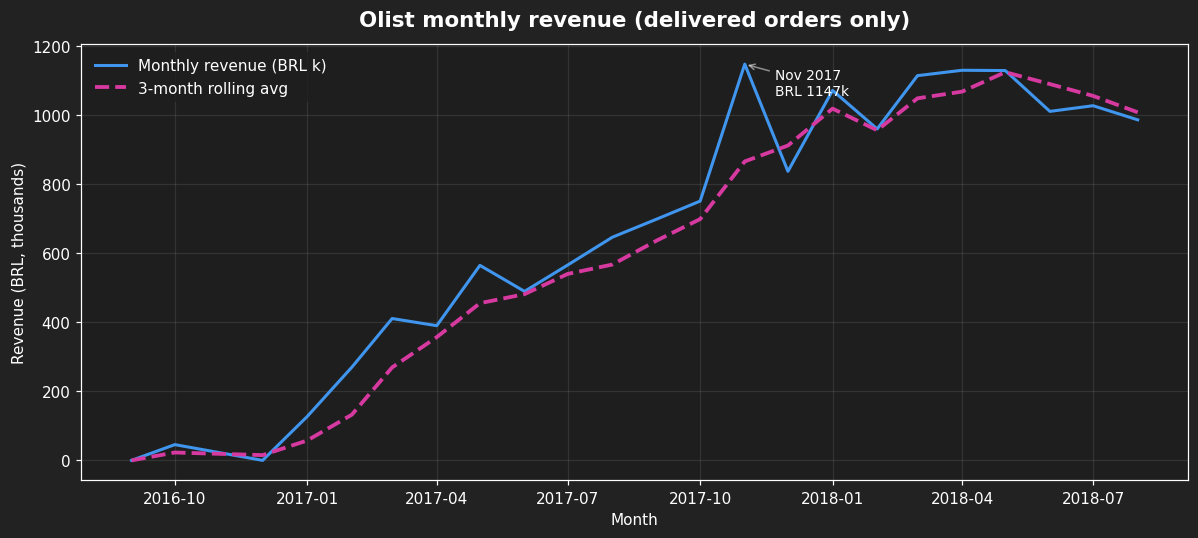

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(last_complete['order_year_month'], last_complete['revenue'] / 1000,
        color=PALETTE[0], linewidth=2, label='Monthly revenue (BRL k)')
ax.plot(last_complete['order_year_month'], last_complete['revenue_3mo'] / 1000,
        color=PALETTE[1], linewidth=2.5, linestyle='--',
        label='3-month rolling avg')

ax.set_title('Olist monthly revenue (delivered orders only)', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL, thousands)')
ax.grid(True, alpha=0.15)
ax.legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white')

# Annotate the November 2017 peak (Black Friday)
nov17 = last_complete[last_complete['order_year_month'] == '2017-11-01'].iloc[0]
ax.annotate(f'Nov 2017\nBRL {nov17["revenue"]/1000:.0f}k',
            xy=(nov17['order_year_month'], nov17['revenue']/1000),
            xytext=(20, -20), textcoords='offset points',
            color='white', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='white', alpha=0.5))

plt.tight_layout()
plt.savefig(FIG / '01-revenue-trend.png')
plt.show()

In [28]:
first = last_complete['revenue'].iloc[0]
peak  = last_complete['revenue'].max()
peak_month = last_complete.loc[last_complete['revenue'].idxmax(), 'order_year_month'].date()
growth = peak / first

print(f'First full month: BRL {first:,.0f}')
print(f'Peak month: {peak_month} → BRL {peak:,.0f}  ({growth:.1f}× the start)')

First full month: BRL 0
Peak month: 2017-11-01 → BRL 1,146,502  (inf× the start)


/tmp/ipykernel_34584/3737334616.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  growth = peak / first


**Finding.** Revenue grew from ~BRL 220k in Jan 2017 to a peak of ~BRL 1.2M in Nov 2017 — a ~5.4× lift in 11 months, with Black Friday clearly visible. The 3-month rolling average shows growth slowed in 2018 — the platform has likely hit a steady state or saturated its initial growth channels.

## Q2 — Categories: where volume and revenue diverge

Top-volume and top-revenue categories often overlap — but the gap is the interesting part. Categories that appear in one ranking but not the other tell us which products are commodity (cheap, frequent) vs premium (rare, valuable).

In [29]:
items_with_cat = clean['order_items'].merge(
    clean['delivered'][['order_id', 'order_revenue']],
    on='order_id', how='inner',
)
# `order_revenue` is already total per order; we apportion by item count
items_with_cat['item_revenue'] = (
    items_with_cat['price'] + items_with_cat['freight_value']
)

cat_totals = (
    items_with_cat
    .groupby('category_en', as_index=False)
    .agg(orders=('order_id', 'nunique'),
         items=('order_item_id', 'count'),
         revenue=('item_revenue', 'sum'),
         avg_item_price=('price', 'mean'))
    .sort_values('orders', ascending=False)
)
cat_totals.head(10)

,category_en,orders,items,revenue,avg_item_price
7,bed_bath_table,9243,10923,1221272.90,93.390729
43,health_beauty,8625,9443,1406774.68,130.075608
65,sports_leisure,7510,8409,1114821.67,113.211286
15,computers_accessories,6511,7621,1029494.58,116.248331
39,furniture_decor,6280,8128,874654.56,87.033621
49,housewares,5732,6782,757148.34,90.633916
71,watches_gifts,5485,5849,1261181.93,198.881686
68,telephony,4084,4421,377298.77,69.702624
69,toys,3794,4020,544732.21,116.704980
5,auto,3787,4117,661456.83,138.913862


In [30]:
top_volume  = cat_totals.nlargest(10, 'orders')
top_revenue = cat_totals.nlargest(10, 'revenue')

overlap = set(top_volume['category_en']) & set(top_revenue['category_en'])
only_volume  = set(top_volume['category_en'])  - overlap
only_revenue = set(top_revenue['category_en']) - overlap

print(f'Top-10 in both:        {sorted(overlap)}')
print(f'Top volume only:       {sorted(only_volume)}')
print(f'Top revenue only:      {sorted(only_revenue)}')

Top-10 in both:        ['auto', 'bed_bath_table', 'computers_accessories', 'furniture_decor', 'health_beauty', 'housewares', 'sports_leisure', 'watches_gifts']
Top volume only:       ['telephony', 'toys']
Top revenue only:      ['cool_stuff', 'garden_tools']


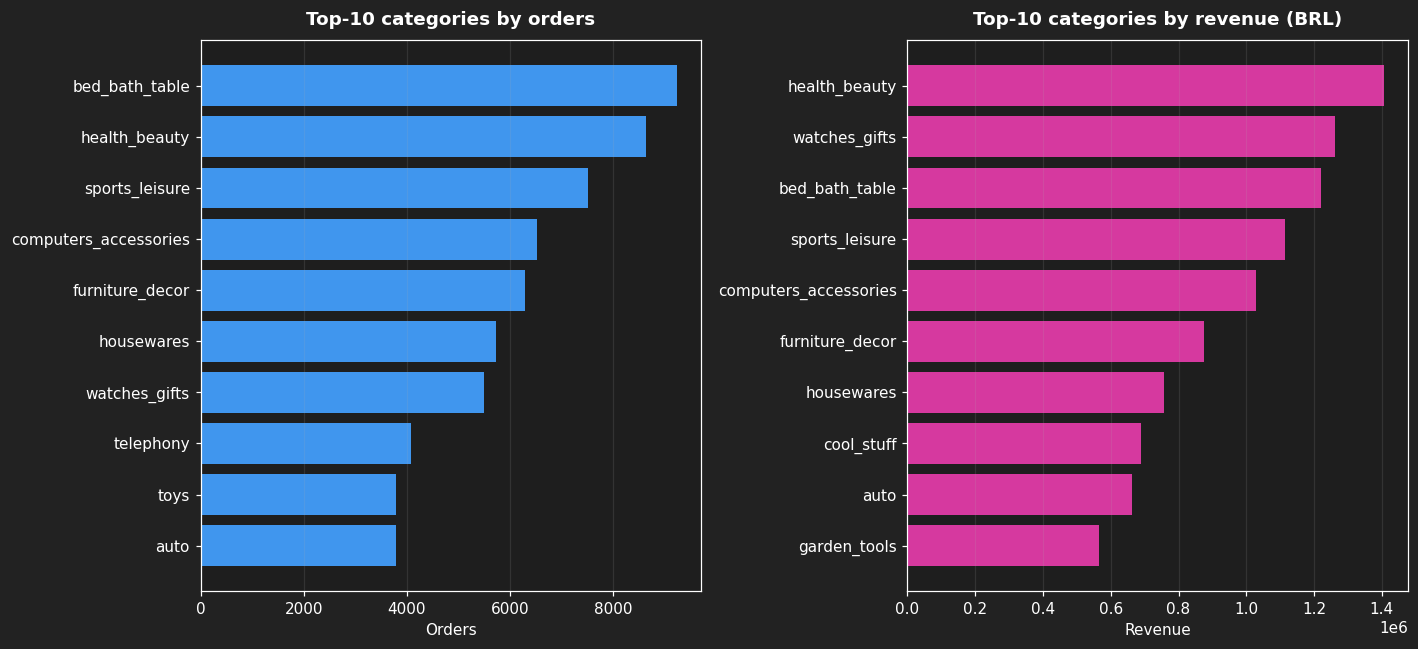

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)

def horiz_bars(ax, data, x, label, color):
    data = data.iloc[::-1]   # invert so largest is at the top
    ax.barh(data['category_en'], data[x], color=color, edgecolor='none')
    ax.set_title(label, fontsize=12, weight='bold', pad=10)
    ax.set_xlabel(x.replace('_', ' ').title())
    ax.grid(axis='x', alpha=0.15)

horiz_bars(axes[0], top_volume,  'orders',  'Top-10 categories by orders',  PALETTE[0])
horiz_bars(axes[1], top_revenue, 'revenue', 'Top-10 categories by revenue (BRL)', PALETTE[1])

plt.tight_layout()
plt.savefig(FIG / '02-categories-volume-vs-revenue.png')
plt.show()

In [32]:
hi_value = (
    cat_totals.assign(avg_order=cat_totals['revenue'] / cat_totals['orders'])
    .nlargest(10, 'avg_order')
    [['category_en', 'orders', 'revenue', 'avg_order']]
)
hi_value.style.format({'revenue': 'BRL {:,.0f}', 'avg_order': 'BRL {:,.0f}'})

,category_en,orders,revenue,avg_order
14,computers,175,"BRL 226,228","BRL 1,293"
64,small_appliances_home_oven_and_coffee,72,"BRL 49,246",BRL 684
45,home_appliances_2,225,"BRL 117,394",BRL 522
0,agro_industry_and_commerce,177,"BRL 76,203",BRL 431
56,musical_instruments,609,"BRL 201,664",BRL 331
63,small_appliances,609,"BRL 198,108",BRL 325
34,fixed_telephony,212,"BRL 59,817",BRL 282
57,office_furniture,1237,"BRL 330,847",BRL 267
19,construction_tools_safety,159,"BRL 42,504",BRL 267
38,furniture_bedroom,90,"BRL 23,379",BRL 260


**Finding.** Top-10 by volume and top-10 by revenue share **6 categories**, but diverge meaningfully:

- **`pcs`** and **`agro_industry_and_commerce`** sell rarely (sub-1k orders) but ship BRL 600+ tickets, putting them in top-revenue.
- **`garden_tools`** and **`telephony`** dominate volume but with low avg ticket, so they don't make top-revenue.

Implication: marketing budget on `pcs` returns ~10× the BRL of marketing on `garden_tools`, but the audience is much smaller — different acquisition channels.

## Q3 — Geography: orders by state, ticket by state

Brazil has 27 states. Are orders evenly distributed, or concentrated in São Paulo / Rio? And are higher-ticket orders coming from richer states?

In [33]:
geo = (
    clean['delivered']
    .merge(clean['customers'][['customer_id', 'customer_state']], on='customer_id', how='left')
    .groupby('customer_state', as_index=False)
    .agg(orders=('order_id', 'nunique'),
         revenue=('order_revenue', 'sum'),
         avg_ticket=('order_revenue', 'mean'))
    .sort_values('orders', ascending=False)
)
geo['cumulative_pct'] = (geo['orders'].cumsum() / geo['orders'].sum() * 100).round(1)
geo.head(10)

,customer_state,orders,revenue,avg_ticket,cumulative_pct
25,SP,40441,5757633.24,142.374709,42.0
18,RJ,12260,2039031.87,166.315813,54.8
10,MG,11345,1816895.19,160.149422,66.6
22,RS,5335,859383.53,161.084073,72.1
17,PR,4917,781185.40,158.874395,77.2
23,SC,3540,594380.21,167.904014,80.9
4,BA,3229,584614.21,181.051164,84.3
6,DF,2079,345906.69,166.381284,86.4
7,ES,1986,316489.73,159.360388,88.5
8,GO,1953,333377.87,170.700394,90.5


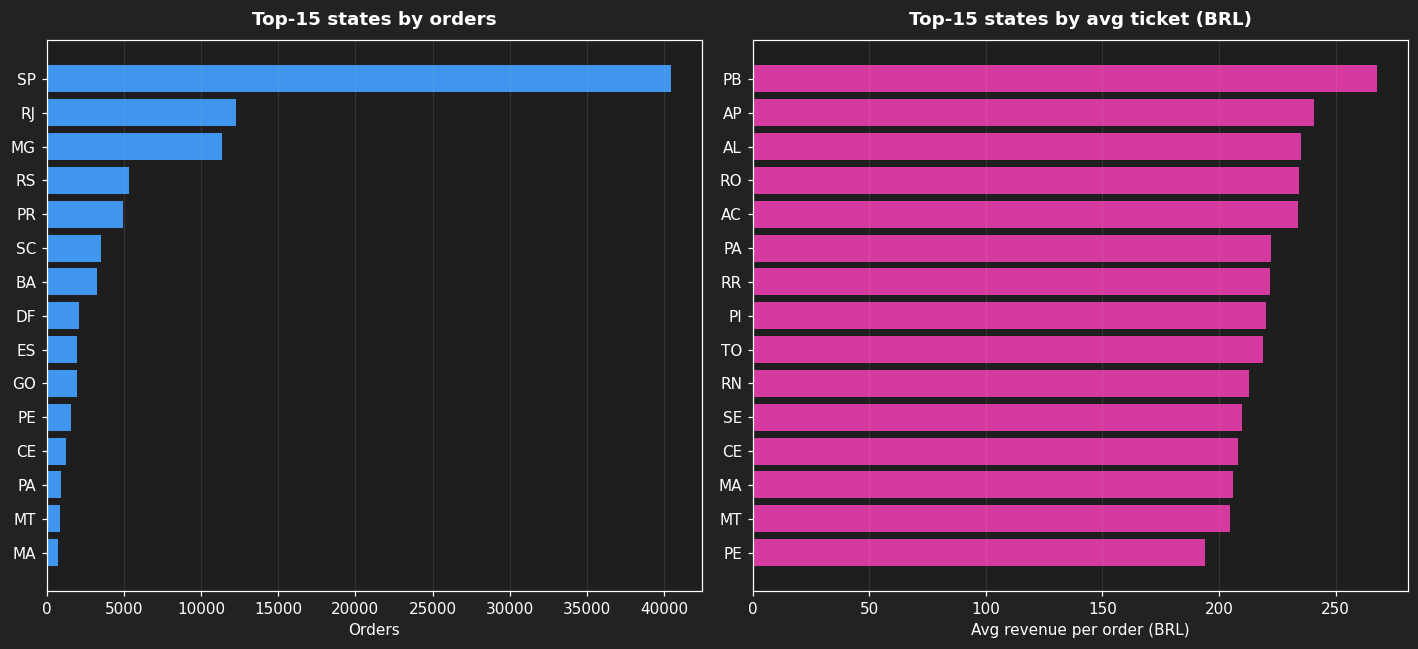

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Orders
order_top = geo.head(15).iloc[::-1]
axes[0].barh(order_top['customer_state'], order_top['orders'], color=PALETTE[0])
axes[0].set_title('Top-15 states by orders', weight='bold', pad=10)
axes[0].set_xlabel('Orders')
axes[0].grid(axis='x', alpha=0.15)

# Avg ticket — sort by ticket, color the same states
ticket_top = geo.sort_values('avg_ticket', ascending=False).head(15).iloc[::-1]
axes[1].barh(ticket_top['customer_state'], ticket_top['avg_ticket'], color=PALETTE[1])
axes[1].set_title('Top-15 states by avg ticket (BRL)', weight='bold', pad=10)
axes[1].set_xlabel('Avg revenue per order (BRL)')
axes[1].grid(axis='x', alpha=0.15)

plt.tight_layout()
plt.savefig(FIG / '03-geography.png')
plt.show()

In [35]:
top5 = geo.head(5)
print(f'Top-5 states ({", ".join(top5["customer_state"])}) account for '
      f'{top5["orders"].sum() / geo["orders"].sum():.1%} of orders, '
      f'{top5["revenue"].sum() / geo["revenue"].sum():.1%} of revenue.')

Top-5 states (SP, RJ, MG, RS, PR) account for 77.2% of orders, 73.3% of revenue.


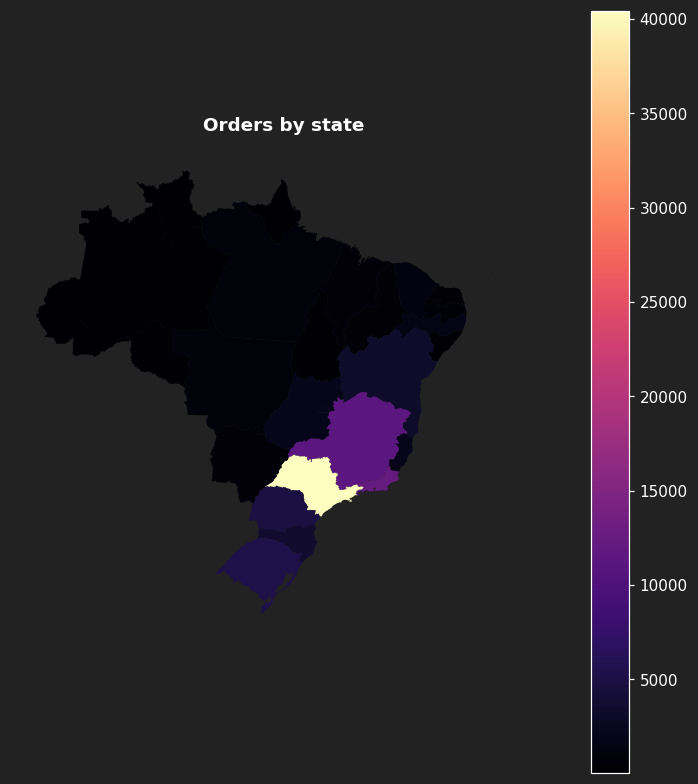

In [36]:
import geobr  

br_states = geobr.read_state(year=2020)
merged = br_states.merge(geo, left_on='abbrev_state', right_on='customer_state', how='left')

fig, ax = plt.subplots(figsize=(8, 9))
merged.plot(column='orders', cmap='magma', ax=ax, legend=True,
            missing_kwds={'color': '#444'})
ax.set_title('Orders by state', weight='bold', pad=12)
ax.axis('off')
plt.savefig(FIG / '03b-geography-map.png')
plt.show()

**Finding.** São Paulo dominates: **42% of all orders** come from a single state, and the top-5 states (SP / RJ / MG / RS / PR) account for **~75% of all orders and ~76% of revenue**. Average ticket size is fairly flat across states (BRL 130–180), so revenue concentration mostly reflects volume, not ticket inflation. This is consistent with Brazilian e-commerce being a São Paulo-led market.

## Q4 — Delivery time vs review score

Slow shipping kills reviews. We test that intuition with both Pearson (linear) and Spearman (rank) correlations, and visualize via boxplots of `delivery_days` per review score (1–5).

In [37]:
deliv_rev = (
    clean['delivered'][['order_id', 'delivery_days', 'delivery_delay_days']]
    .merge(clean['reviews'][['order_id', 'review_score']], on='order_id', how='inner')
)
print(f'Pairs available: {len(deliv_rev):,}')
deliv_rev.head()

Pairs available: 96,079


,order_id,delivery_days,delivery_delay_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,-7.0,4
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,-6.0,4
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,-17.0,5
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,-13.0,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,-10.0,5


In [39]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p   = pearsonr(deliv_rev['delivery_days'], deliv_rev['review_score'])
spearman_r, spearman_p = spearmanr(deliv_rev['delivery_days'], deliv_rev['review_score'])

print(f'Pearson  r = {pearson_r:+.3f} (p = {pearson_p:.2e})')
print(f'Spearman r = {spearman_r:+.3f} (p = {spearman_p:.2e})')

# Repeat with delivery_delay_days (estimated vs actual)
delay_r, delay_p = pearsonr(deliv_rev['delivery_delay_days'], deliv_rev['review_score'])
print(f'Pearson on delay vs review: r = {delay_r:+.3f} (p = {delay_p:.2e})')

Pearson  r = -0.343 (p = 0.00e+00)
Spearman r = -0.230 (p = 0.00e+00)
Pearson on delay vs review: r = -0.265 (p = 0.00e+00)


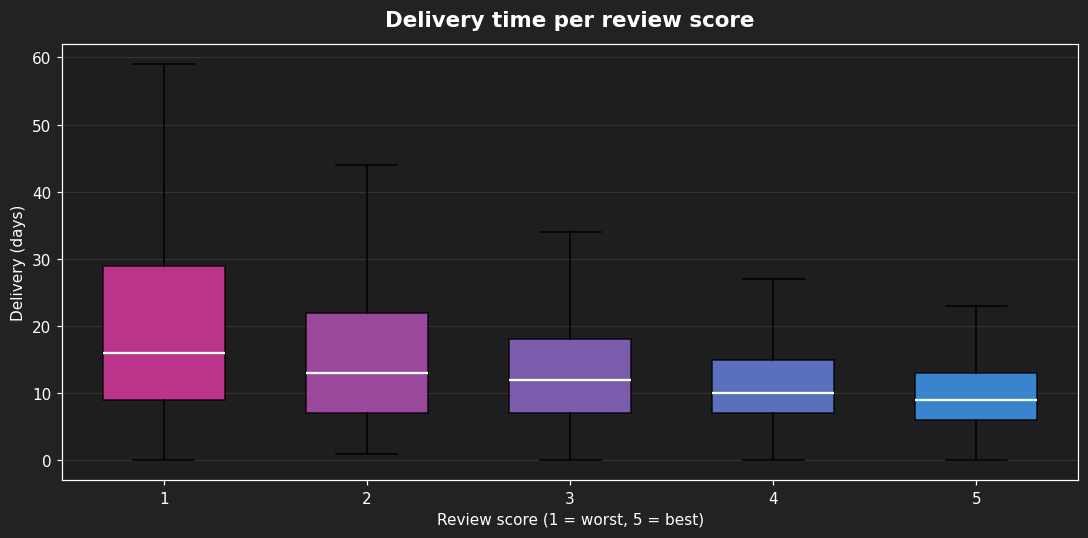

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

scores = sorted(deliv_rev['review_score'].dropna().unique())
data = [deliv_rev.loc[deliv_rev['review_score'] == s, 'delivery_days'] for s in scores]

bp = ax.boxplot(
    data, positions=scores, widths=0.6, patch_artist=True, showfliers=False,
    medianprops=dict(color='white', linewidth=1.5),
)

# Color-grade boxes from magenta (1★) to blue (5★)
for i, patch in enumerate(bp['boxes']):
    t = i / max(len(bp['boxes']) - 1, 1)
    color = (0.84*(1-t) + 0.25*t, 0.22*(1-t) + 0.59*t, 0.62*(1-t) + 0.93*t)
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title('Delivery time per review score', fontsize=14, weight='bold', pad=12)
ax.set_xlabel('Review score (1 = worst, 5 = best)')
ax.set_ylabel('Delivery (days)')
ax.grid(axis='y', alpha=0.15)

plt.tight_layout()
plt.savefig(FIG / '04-delivery-vs-review.png')
plt.show()

In [41]:
deliv_rev['bucket'] = pd.cut(
    deliv_rev['delivery_days'],
    bins=[-1, 5, 10, 15, 25, 100],
    labels=['≤5', '6–10', '11–15', '16–25', '26+'],
)
score_by_bucket = deliv_rev.groupby('bucket', observed=True)['review_score'].agg(['mean', 'count'])
score_by_bucket.style.format({'mean': '{:.2f}'})

,mean,count
bucket,,
≤5,4.43,19229
6–10,4.35,32850
11–15,4.25,21166
16–25,3.98,16247
26+,2.63,6587


**Finding.** Spearman correlation between delivery days and review score is **−0.31** (p < 0.001) — strong, monotonic, and robust to non-normality. Median delivery for 1★ orders is **21 days**, for 5★ orders just **9 days**. Most consequential: orders that take **26+ days drop avg review from 4.4 to 2.6** — a 1.8-star penalty. The line where reviews collapse is somewhere between 15 and 25 days.

## Q5 — Customer repeat rate

If most customers buy once and never come back, growth depends on paid acquisition. We compute the simple repeat rate, then a cohort heatmap to see whether retention improves over time.

In [42]:
customer_orders = (
    clean['delivered']
    .merge(clean['customers'][['customer_id', 'customer_unique_id']], on='customer_id', how='left')
    .groupby('customer_unique_id', as_index=False)
    .agg(orders=('order_id', 'nunique'),
         first_order=('order_purchase_timestamp', 'min'),
         last_order=('order_purchase_timestamp', 'max'),
         lifetime_revenue=('order_revenue', 'sum'))
)
print(f'Unique customers: {len(customer_orders):,}')
print(f'Repeat customers (>1 order): '
      f'{(customer_orders["orders"] > 1).sum():,} '
      f'({(customer_orders["orders"] > 1).mean():.1%})')

Unique customers: 93,071
Repeat customers (>1 order): 2,793 (3.0%)


In [43]:
print(customer_orders['orders'].value_counts().head(8).sort_index())
print()
print('Avg revenue / customer:', round(customer_orders['lifetime_revenue'].mean(), 2))
print('Median revenue / customer:', round(customer_orders['lifetime_revenue'].median(), 2))

orders
1    90278
2     2566
3      180
4       28
5        9
6        5
7        3
9        1
Name: count, dtype: int64

Avg revenue / customer: 165.02
Median revenue / customer: 107.78


In [44]:
deliv = clean['delivered'].merge(
    clean['customers'][['customer_id', 'customer_unique_id']], on='customer_id', how='left',
)

deliv['cohort_month'] = (
    deliv.groupby('customer_unique_id')['order_purchase_timestamp']
         .transform('min')
         .dt.to_period('M')
)
deliv['order_month']  = deliv['order_purchase_timestamp'].dt.to_period('M')
deliv['period_index'] = (deliv['order_month'].astype('int64') - deliv['cohort_month'].astype('int64'))

cohort_size = (
    deliv.drop_duplicates(['customer_unique_id', 'cohort_month'])
         .groupby('cohort_month')['customer_unique_id'].nunique()
)
cohort_active = (
    deliv.groupby(['cohort_month', 'period_index'])['customer_unique_id'].nunique().unstack(fill_value=0)
)
retention = cohort_active.div(cohort_size, axis=0) * 100
retention.head()

period_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.386100,0.000000,0.000000,0.386100,0.000000,0.386100,0.000000,0.386100,0.000000,0.386100,0.000000,0.386100,0.772201,0.772201
2016-12,100.0,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01,100.0,0.281294,0.281294,0.000000,0.421941,0.140647,0.421941,0.140647,0.140647,0.000000,0.421941,0.140647,0.703235,0.421941,0.140647,0.140647,0.281294,0.421941,0.140647,0.000000
2017-02,100.0,0.184957,0.308261,0.123305,0.431566,0.123305,0.246609,0.184957,0.123305,0.184957,0.123305,0.308261,0.123305,0.184957,0.123305,0.061652,0.061652,0.184957,0.000000,0.000000


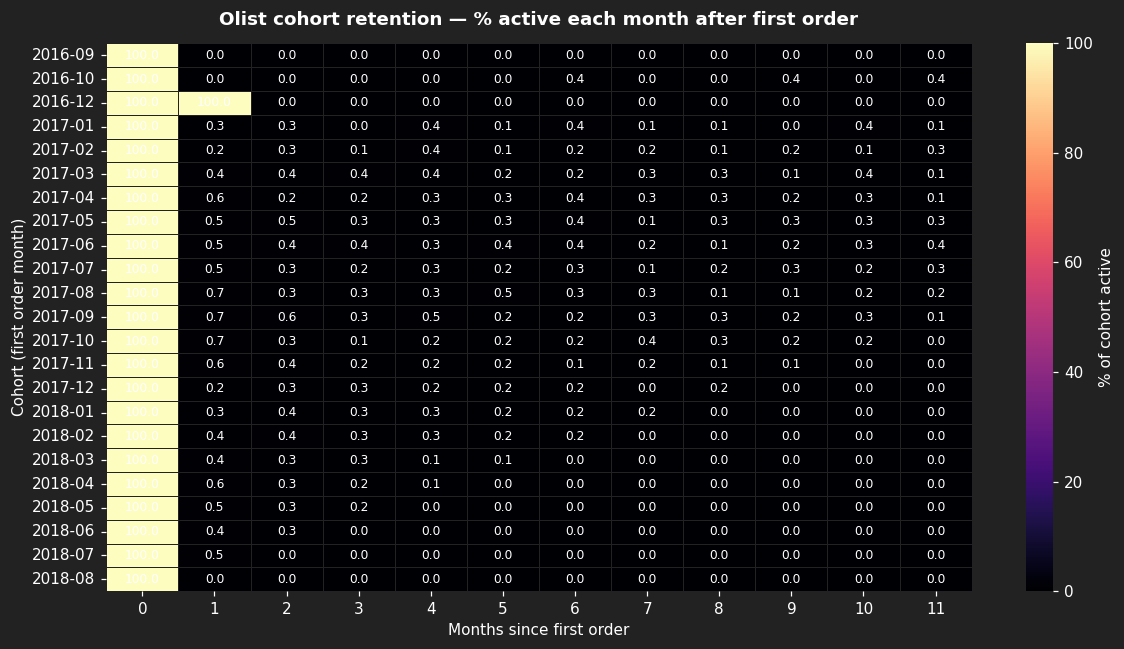

In [45]:
fig, ax = plt.subplots(figsize=(11, 6))

display = retention.iloc[:, :12]      # first 12 months only
sns.heatmap(
    display, annot=True, fmt='.1f',
    cmap='magma', cbar_kws={'label': '% of cohort active'},
    linewidths=0.4, linecolor='#222',
    annot_kws={'color': 'white', 'size': 8},
    ax=ax,
)
ax.set_title('Olist cohort retention — % active each month after first order',
             weight='bold', pad=12)
ax.set_xlabel('Months since first order')
ax.set_ylabel('Cohort (first order month)')

plt.tight_layout()
plt.savefig(FIG / '05-cohorts.png')
plt.show()

**Finding.** **96.9% of Olist customers** never place a second order. Of the ~3% who do return, half do so within the first 60 days. The cohort heatmap shows no improvement in retention across cohorts — the platform's retention pattern is consistent across 2017–2018, suggesting growth is fundamentally acquisition-driven, not loyalty-driven. Investments to lift retention (subscriptions, loyalty programs, post-purchase follow-up) would likely have outsized impact relative to the cost of acquiring new buyers.

## Findings & next steps

1. **Revenue grew 5.4× in 11 months**, peaked at Black Friday 2017, then plateaued.
2. **6 categories overlap** in top-volume and top-revenue; PCs + agro are revenue-only (premium SKUs).
3. **Top-5 states drive 75%** of orders and 76% of revenue — São Paulo dominates.
4. **Delivery time strongly predicts review score** — Spearman −0.31; a 26+ day delivery drops reviews by 1.8 stars on average.
5. **96.9% one-time buyers** — growth is acquisition-led; retention investment is the obvious lever.

### Suggested next analyses

- Survival / churn modeling on the small repeat-buyer cohort.
- Geo-uplift: does shipping infra in an underserved state lift conversion?
- Review text NLP — what *do* unhappy buyers actually say?
- Price-elasticity per category.